In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

hours = np.random.rand(100) * 10
scores = 10 + 8 * hours + np.random.normal(0, 5, 100)

data = pd.DataFrame({
    'Hours': hours,
    'Score': scores
})

In [2]:
data.head()

,Hours,Score
0,3.745401,40.398445
1,9.507143,84.562108
2,7.319939,69.018319
3,5.986585,47.954834
4,1.560186,21.383132


In [11]:
hours_test,hours_train,scores_test,scores_train = train_test_split(data[['Hours']],data['Score'],test_size=0.2,random_state=42)


In [12]:
model = LinearRegression()

In [13]:
model.fit(hours_train,scores_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.66]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [18]:
scores_pred = model.predict(hours_test)

In [19]:
mae = mean_absolute_error(scores_test,scores_pred)
print(f"mean absolute error:{mae:.2f}")

mean absolute error:3.76


In [31]:
print(f"model.intercept_:{model.intercept_:.2f}")


model.intercept_:12.50


In [38]:
print(f"model.coef_:{model.coef_[0]:.2f}")

model.coef_:7.66


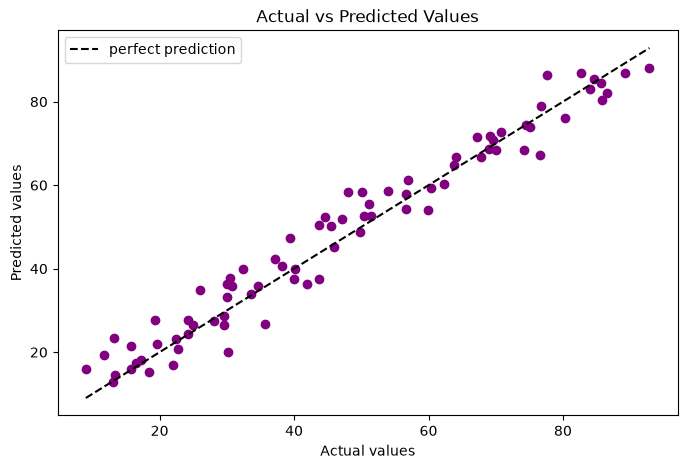

In [37]:
plt.figure(figsize=(8,5))
plt.scatter(scores_test,scores_pred,color='purple')
min_val= min(scores_test.min(),scores_pred.min())
max_val= max(scores_test.max(),scores_pred.max())
plt.plot([min_val,max_val],[min_val,max_val],color='black',linestyle='--',
label='perfect prediction')   
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()